# Feature Engineering, Model Optimization & Performance Comparison


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset


In [86]:

housing = fetch_california_housing(as_frame=True)

df = housing.frame

# Show first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [87]:
# Check dataset information
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nSummary Statistics:")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Summary Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486 

# Feature Engineering

In [88]:
# Create a new feature: Rooms per Household
df["RoomsPerHousehold"] = df["AveRooms"] / df["AveOccup"]

# Create a new feature: Bedrooms per Room
df["BedroomsPerRoom"] = df["AveBedrms"] / df["AveRooms"]

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomsPerRoom
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096


# Define Features (X) and Target (y)

In [89]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (16512, 10)
Testing data shape: (4128, 10)


# Feature Scaling

In [90]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training data shape: (16512, 10)
Scaled testing data shape: (4128, 10)


# Train Linear Regression Model

In [91]:

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


# Evaluate Linear Regression Model

In [92]:


mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-----------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Linear Regression Performance
-----------------------------
Mean Absolute Error (MAE): 0.48616440254149695
Mean Squared Error (MSE): 0.4560938979025374
Root Mean Squared Error (RMSE): 0.675347242463118
R2 Score: 0.6519453808117215


# Train Ridge Regression Model

In [93]:


ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Ridge Regression model trained successfully!")

Ridge Regression model trained successfully!


# Evaluate Ridge Regression Model

In [94]:


mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance")
print("----------------------------")
print("Mean Absolute Error (MAE):", mae_ridge)
print("Mean Squared Error (MSE):", mse_ridge)
print("Root Mean Squared Error (RMSE):", rmse_ridge)
print("R2 Score:", r2_ridge)

Ridge Regression Performance
----------------------------
Mean Absolute Error (MAE): 0.48616430237336716
Mean Squared Error (MSE): 0.45610555489098953
Root Mean Squared Error (RMSE): 0.6753558727744874
R2 Score: 0.6519364851244622


# Evaluate Linear Regression Model

In [95]:


mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

Linear Regression Performance
MAE : 0.48616440254149695
MSE : 0.4560938979025374
RMSE : 0.675347242463118
R2 Score : 0.6519453808117215


# Train Decision Tree Model

In [96]:


tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


# Compare Model Performance

In [97]:


print("Model Performance Comparison")
print("-" * 40)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print("R2  :", r2_score(y_test, y_pred_linear))
print()

print("Ridge Regression")
print("MAE :", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2  :", r2_score(y_test, y_pred_ridge))
print()

print("Decision Tree")
print("MAE :", mean_absolute_error(y_test, y_pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))
print("R2  :", r2_score(y_test, y_pred_tree))

Model Performance Comparison
----------------------------------------
Linear Regression
MAE : 0.48616440254149695
RMSE: 0.675347242463118
R2  : 0.6519453808117215

Ridge Regression
MAE : 0.48616430237336716
RMSE: 0.6753558727744874
R2  : 0.6519364851244622

Decision Tree
MAE : 0.4630718750000001
RMSE: 0.7172055260712791
R2  : 0.6074631850296905


# Model Comparison Graph

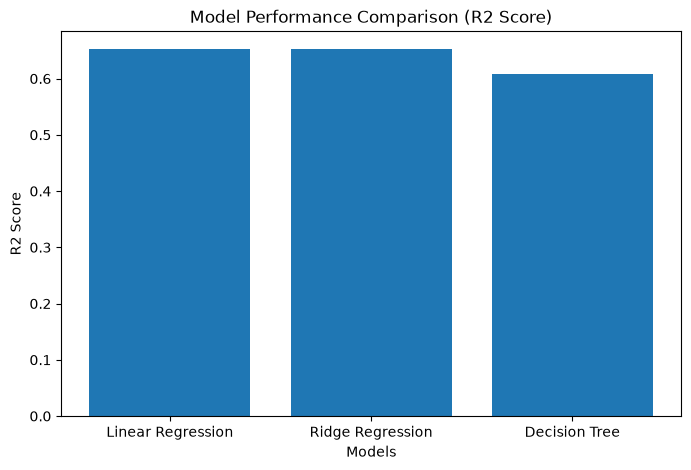

In [98]:


models = ["Linear Regression", "Ridge Regression", "Decision Tree"]
r2_scores = [
    r2_score(y_test, y_pred_linear),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_tree)
]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)
plt.title("Model Performance Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()